## Week 2: Velocity Verlet Integrator

### A slightly more sophisticated version of the Euler integrator implemented in the previous task that is significantly more stable and lets us use much longer time steps.

##### Input: Initial positons and velocities of atoms AND potential energy (atom-atom interactions)
##### Output: Series of snapshot positions and velocities (MD trajectory/movie)

In [1]:
#libraries

import numpy as np
import matplotlib.pyplot as plt
import random


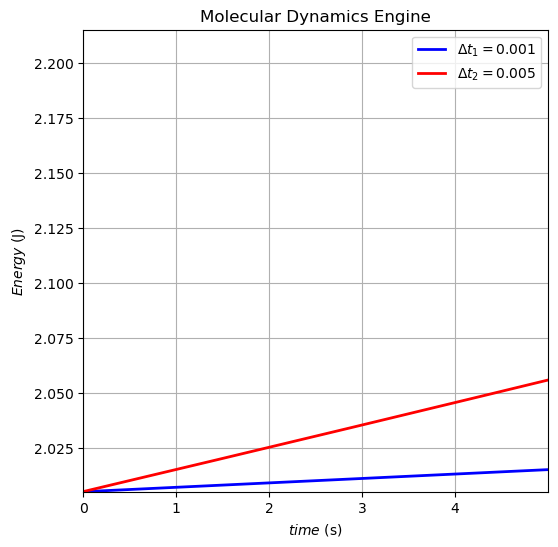

In [2]:
#Code from Project 1:


def BasicMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1, dt_step = 0.001):
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy!'''

    
    time = np.arange(snapshots, dtype=float) * dt_step
    energy = np.zeros(snapshots, dtype=float)
    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)
    x = float(initial_pos) ; v = float(initial_vel)
    k = float(potential_e) 

    for i in range(snapshots):
        x_next = x + (v * dt_step)
        x_step[i] = x_next
        F = -k * x
        force[i] = F 
        v_next = v + ((1/m) * F * dt_step) 
        v_step[i] = v_next
        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)
        energy[i] = pe + ke
        x = x_next ; v = v_next



    return time, x_step, v_step, energy

  

time_a, x_a, v_a, energy_a = BasicMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.001)

time_b, x_b, v_b, energy_b = BasicMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.005)



 
plt.figure(figsize=(6,6))

plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

plt.xlim(time_a.min(), time_a.max()) ; plt.ylim(energy_a.min(), energy_a.max() + 0.2)


plt.plot(time_a, energy_a, "b-", linewidth=2, label = "$Δt_1 = 0.001$")
plt.plot(time_b, energy_b, "r-", linewidth=2, label = "$Δt_2 = 0.005$")
plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()




#### Task 1: Implement the Velocity Verlet Algorithm. 

In [3]:

def VerletMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1, dt_step = 0.001):
    '''XYZ'''

    
    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = float(initial_pos) ; v = float(initial_vel) ; v_halfstep = float(initial_vel)

    k = float(potential_e) 
    
    
    for i in range(snapshots):

        F = -k * x
        force[i] = F 
        v_halfstep = v + ((1/(2*m)) * F * dt_step) 

        x_next = x + (v_halfstep * dt_step)
        x_step[i] = x_next

        F_step = -k * x_next

        v_next = v_halfstep + ((1/(2*m)) * F_step * dt_step) 
        v_step[i] = v_next

        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe + ke

        x = x_next ; v = v_next



    return time, x_step, v_step, energy

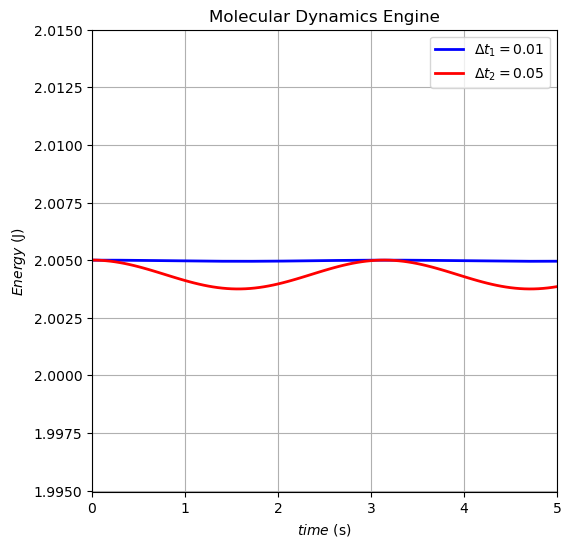

In [4]:
time_a2, x_a2, v_a2, energy_a2 = VerletMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.01)

time_b2, x_b2, v_b2, energy_b2 = VerletMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.05)


plt.figure(figsize=(6,6))

plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

plt.xlim(0, 5) ; plt.ylim(energy_a2.min()-.01, energy_a2.max()+.01)


plt.plot(time_a2, energy_a2, "b-", linewidth=2, label = "$Δt_1 = 0.01$")
plt.plot(time_b2, energy_b2, "r-", linewidth=2, label = "$Δt_2 = 0.05$")
plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()




#### Task 2: Compare the behavior of the Euler and Velocity Verlet Algorithm as you increase Delta t
Make a plot of Energy as a function of time for different time steps Delta t for both Euler and Velocity Verlet. This time, instead of reporting what Delta t is, report Delta t * omega. Where omega = sqrt(k/m). Omega is called the frequency of the Harmonic Oscillator (units are 1/s), and gives us a convenient time scale to compare Delta t to.  Look at Delta t * omega values between 0.01 and 10.

In [ ]:
def BasicMDEngine(initial_pos, initial_vel, potential_e = 1.0, snapshots=50, m=1, dt_step = 0.001):
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy!'''

    
    time = np.arange(snapshots, dtype=float) * dt_step
    energy = np.zeros(snapshots, dtype=float)
    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)
    x = float(initial_pos) ; v = float(initial_vel)
    k = float(potential_e) 

    #omega = np.sqrt(k/m)

    for i in range(snapshots):
        x_next = x + (v * dt_step)
        x_step[i] = x_next
        F = -k * x
        force[i] = F 
        v_next = v + ((1/m) * F * dt_step) 
        v_step[i] = v_next
        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)
        energy[i] = pe + ke
        x = x_next ; v = v_next



    return time, x_step, v_step, energy


def VerletMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1, dt_step = 0.001):
    '''XYZ'''


    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = float(initial_pos) ; v = float(initial_vel) ; v_halfstep = float(initial_vel)

    k = float(potential_e) 

    omega = np.sqrt(k/m)


    for i in range(snapshots):

        F = -k * x
        force[i] = F 
        v_halfstep = v + ((1/(2*m)) * F * dt_step) 

        x_next = x + (v_halfstep * dt_step)
        x_step[i] = x_next

        F_step = -k * x_next

        v_next = v_halfstep + ((1/(2*m)) * F_step * dt_step) 
        v_step[i] = v_next

        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe + ke

        x = x_next ; v = v_next



    return time, x_step, v_step, energy

In [6]:
#old code

'''random.seed(2)

timescale = [0.01, 0.1, 0.5, 1.0]
#[0.01, 0.1, 1.0, 5.0, 10.0]

#------------
#print(plt.subplots(2,3)) - 2 rows, 3 columns     2,1
#plt.plot(time_a2, energy_a2, "b-", linewidth=2, label = "$ωΔt$")
#plt.plot(time_b2, energy_b2, "r-", linewidth=2, label = "$ωΔt$")

x_i = 2.0 ; v_i = 0.1 ; k = 1.0 ; snapshots = 5000 ; m=1

omega = np.sqrt(k/m)

color_list = ['red', 'blue', 'green', 'orange', 'black', 'brown', 'purple', 'gray', 'pink']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,12))

for t in timescale:
    dt = t/omega

    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    time, x, v, energy = BasicMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax1.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$Δt$ = " + str(dt))


#ax1.figure(figsize=(12,12))
ax1.set_xlabel('$time$ (s)') ; ax1.set_ylabel('$Energy$ (J)') 
ax1.set_xlim(0, 5) ; ax1.set_ylim(0, 5)
ax1.legend(loc="upper right") ; ax1.set_title("Euler Molecular Dynamics Engine") ; ax1.grid(True) ; 


for t in timescale:
    dt = t/omega

    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    time, x, v, energy = VerletMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax2.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$Δt$ = " + str(dt))

#ax2.figure(figsize=(12,12))
ax2.set_xlabel('$time$ (s)') ; ax2.set_ylabel('$Energy$ (J)') 
ax2.set_xlim(0, 5) ; ax2.set_ylim(0, 5)
ax2.legend(loc="upper right") ; ax2.set_title("Verlet Molecular Dynamics Engine") ; ax2.grid(True) ; 

 
plt.show()
'''

'random.seed(2)\n\ntimescale = [0.01, 0.1, 0.5, 1.0]\n#[0.01, 0.1, 1.0, 5.0, 10.0]\n\n#------------\n#print(plt.subplots(2,3)) - 2 rows, 3 columns     2,1\n#plt.plot(time_a2, energy_a2, "b-", linewidth=2, label = "$ωΔt$")\n#plt.plot(time_b2, energy_b2, "r-", linewidth=2, label = "$ωΔt$")\n\nx_i = 2.0 ; v_i = 0.1 ; k = 1.0 ; snapshots = 5000 ; m=1\n\nomega = np.sqrt(k/m)\n\ncolor_list = [\'red\', \'blue\', \'green\', \'orange\', \'black\', \'brown\', \'purple\', \'gray\', \'pink\']\n\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,12))\n\nfor t in timescale:\n    dt = t/omega\n\n    selected_color = random.choice(color_list)\n    color_list.remove(selected_color)\n\n    time, x, v, energy = BasicMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)\n    ax1.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$Δt$ = " + str(dt))\n\n\n#ax1.figure(figsize=(12,12))\nax1.set_xlabel(\'$time$ (s)\') ; ax1.set_ylabel(

C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:21: RuntimeWarning: overflow encountered in power
  ke = 0.5 * m * np.power(v_next, 2)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:20: RuntimeWarning: overflow encountered in power
  pe = 0.5 * k * np.power(x_next, 2)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: overflow encountered in scalar add
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: invalid value encountered in scalar add
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x_next = x + (v * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: overflow encountered in scalar multiply
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:62: RuntimeWarnin

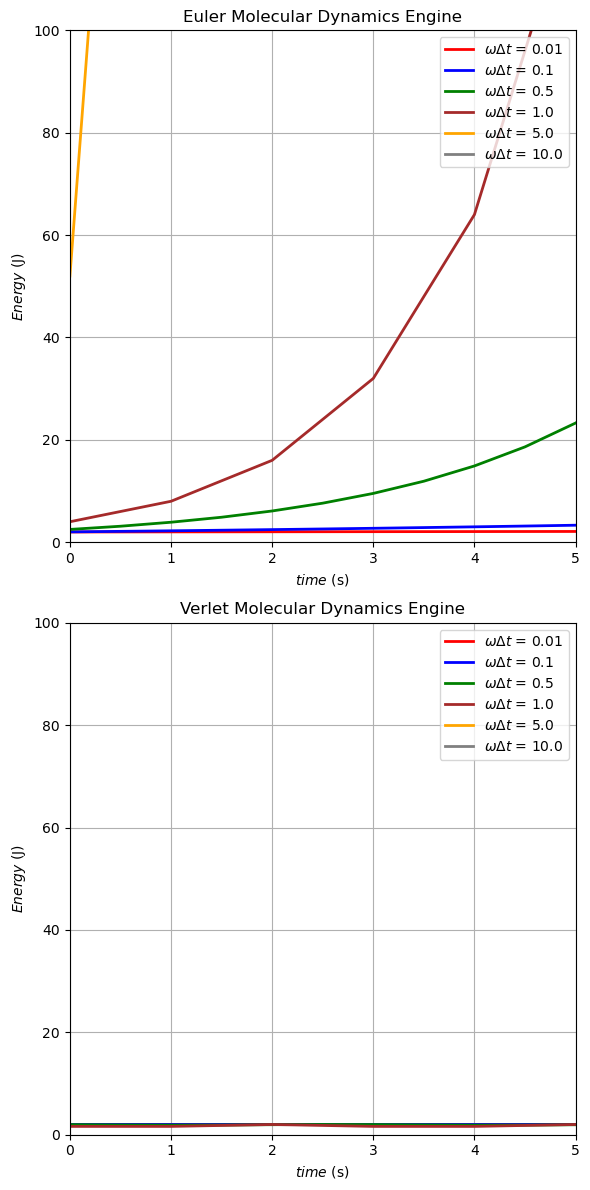

In [10]:
random.seed(2)

timescale = [0.01, 0.1, 0.5, 1.0, 5.0, 10]

x_i = 2.0 ; v_i = 0 ; k = 1.0 ; snapshots = 5000 ; m=1

omega = np.sqrt(k/m)

color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,12))

for t in timescale:
    dt = t/omega

    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    time, x, v, energy = BasicMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax1.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))

    time, x, v, energy = VerletMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax2.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))


ax1.set_xlabel('$time$ (s)') ; ax1.set_ylabel('$Energy$ (J)') 
ax1.set_xlim(0, 5) ; ax1.set_ylim(0, 100)
ax1.legend(loc="upper right") ; ax1.set_title("Euler Molecular Dynamics Engine") ; ax1.grid(True) ; 

ax2.set_xlabel('$time$ (s)') ; ax2.set_ylabel('$Energy$ (J)') 
ax2.set_xlim(0, 5) ; ax2.set_ylim(0, 100)
ax2.legend(loc="upper right") ; ax2.set_title("Verlet Molecular Dynamics Engine") ; ax2.grid(True) ; 


plt.tight_layout()

plt.show()

#### Task 3: This time also make 2 other plots. x(t) and v(t) (Also do this for different values of Delta t * omega and for both integrators just like you did with energy.
For this, I’d like you to make a python figure with 3 subplots one on top of the other. One for x(t), one for v(t) and one for E(t).

C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:21: RuntimeWarning: overflow encountered in power
  ke = 0.5 * m * np.power(v_next, 2)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:20: RuntimeWarning: overflow encountered in power
  pe = 0.5 * k * np.power(x_next, 2)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: overflow encountered in scalar add
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: invalid value encountered in scalar add
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x_next = x + (v * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:18: RuntimeWarning: overflow encountered in scalar multiply
  v_next = v + ((1/m) * F * dt_step)
C:\Users\ahajt\AppData\Local\Temp\ipykernel_4236\352101507.py:62: RuntimeWarnin

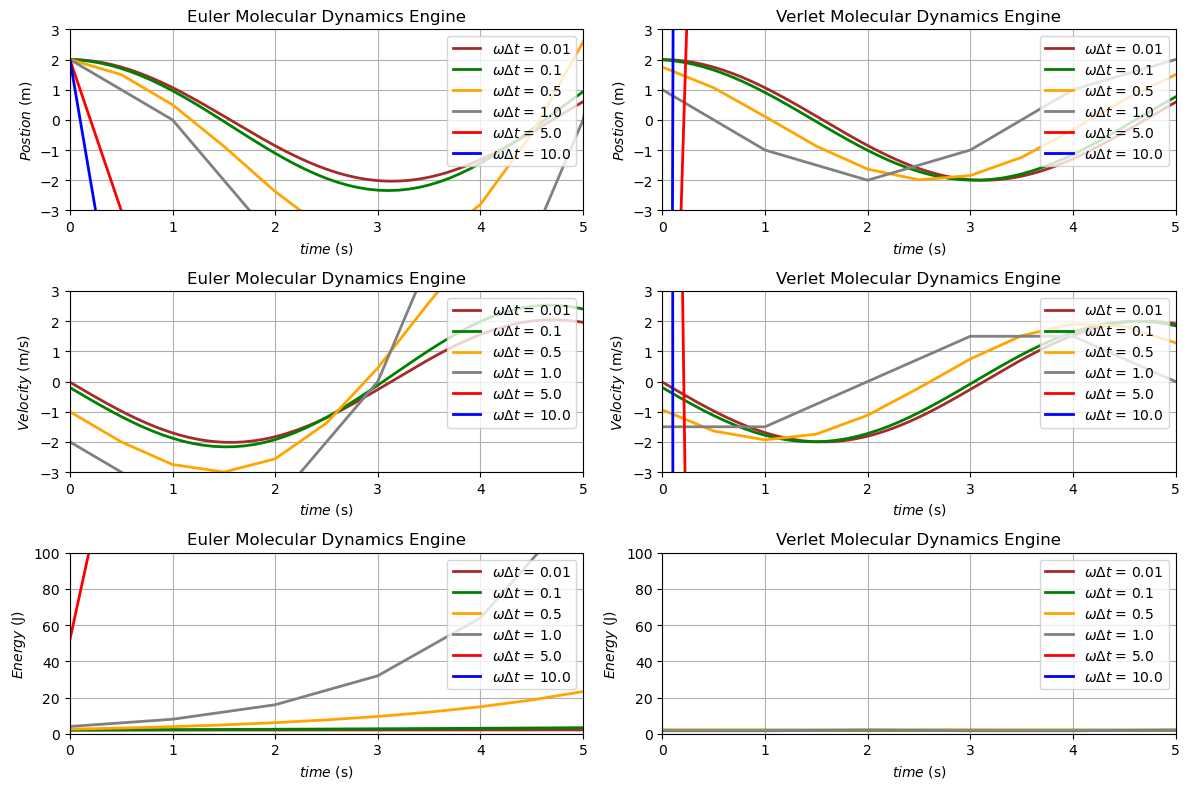

<Figure size 640x480 with 0 Axes>

In [14]:
random.seed(5)

fig, ((ax1_x, ax2_x),
      (ax1_v, ax2_v),
      (ax1_e, ax2_e)) = plt.subplots(3,2, figsize=(12, 8))

color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for t in timescale:
    dt = t/omega

    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    time, x, v, energy = BasicMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax1_x.plot(time, x, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))
    ax1_v.plot(time, v, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))
    ax1_e.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))

    time, x, v, energy = VerletMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e=k, snapshots = snapshots, m=m, dt_step = dt)
    ax2_x.plot(time, x, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))
    ax2_v.plot(time, v, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))
    ax2_e.plot(time, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))



ax1_x.set_xlabel('$time$ (s)') ; ax1_x.set_ylabel('$Postion$ (m)') 
ax1_x.set_xlim(0, 5) ; ax1_x.set_ylim(-3, 3)
ax1_x.legend(loc="upper right") ; ax1_x.set_title("Euler Molecular Dynamics Engine") ; ax1_x.grid(True) ; 

ax1_v.set_xlabel('$time$ (s)') ; ax1_v.set_ylabel('$Velocity$ (m/s)') 
ax1_v.set_xlim(0, 5) ; ax1_v.set_ylim(-3, 3)
ax1_v.legend(loc="upper right") ; ax1_v.set_title("Euler Molecular Dynamics Engine") ; ax1_v.grid(True) ; 

ax1_e.set_xlabel('$time$ (s)') ; ax1_e.set_ylabel('$Energy$ (J)') 
ax1_e.set_xlim(0, 5) ; ax1_e.set_ylim(0, 100)
ax1_e.legend(loc="upper right") ; ax1_e.set_title("Euler Molecular Dynamics Engine") ; ax1_e.grid(True) ; 

# --------------------

ax2_x.set_xlabel('$time$ (s)') ; ax2_x.set_ylabel('$Postion$ (m)') 
ax2_x.set_xlim(0, 5) ; ax2_x.set_ylim(-3, 3)
ax2_x.legend(loc="upper right") ; ax2_x.set_title("Verlet Molecular Dynamics Engine") ; ax2_x.grid(True) ; 

ax2_v.set_xlabel('$time$ (s)') ; ax2_v.set_ylabel('$Velocity$ (m/s)') 
ax2_v.set_xlim(0, 5) ; ax2_v.set_ylim(-3, 3)
ax2_v.legend(loc="upper right") ; ax2_v.set_title("Verlet Molecular Dynamics Engine") ; ax2_v.grid(True) ; 

ax2_e.set_xlabel('$time$ (s)') ; ax2_e.set_ylabel('$Energy$ (J)') 
ax2_e.set_xlim(0, 5) ; ax2_e.set_ylim(0, 100)
ax2_e.legend(loc="upper right") ; ax2_e.set_title("Verlet Molecular Dynamics Engine") ; ax2_e.grid(True) ; 


plt.tight_layout()

plt.show()
plt.savefig("MD_Engine_Stats.pdf")

#### Task 4 (Optional): Make an animation of x(t) and p(t) = mv(t) for one value of Delta t and the Velocity Verlet integrator. This time, set up an axis where the x coordinate is x and the y coordinate is p (the momentum). Instead of making a single static plot, make an animation using matplotlib. Each frame in your animation should have a scatter point at x=x(t), y=p(t) and a line that draws the trajectory from x(0) up until x(t).

These plots of x vs p are called phase space plots and play a very important role in classical mechanics.

Animation size has reached 20992924 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
MovieWriter ffmpeg unavailable; using Pillow instead.


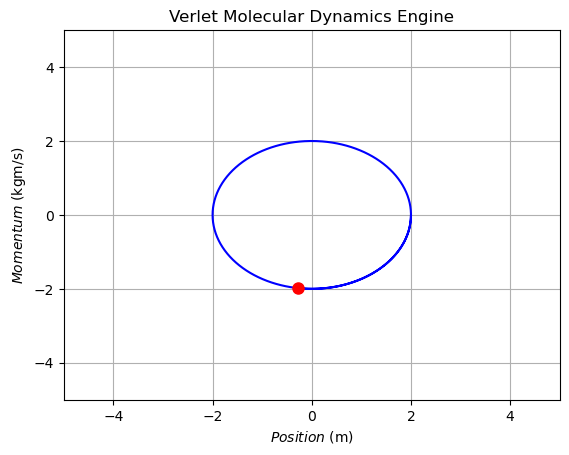

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML #Not sure if i need this import

m=1;k=1

omega = np.sqrt(k/m) ; dt = 0.01/omega

time, x, v, energy = VerletMDEngine(initial_pos=x_i, initial_vel=v_i, potential_e= k, snapshots = snapshots, m=m, dt_step = dt)

p = m * v #momentum

fig, axis = plt.subplots()

axis.set_xlabel('$Position$ (m)') ; axis.set_ylabel('$Momentum$ (kgm/s)') 
axis.set_xlim(-5, 5) ; axis.set_ylim(-5, 5)
axis.set_title("Verlet Molecular Dynamics Engine") ; axis.grid(True)

#This part I got help from a youtube video -------------------------------------

ani_line, = axis.plot([], [], 'b-')  #line tracked
ani_point, = axis.plot([], [], 'ro', markersize=8)  #position point

def update_data(frame):
    
    if frame > 0:
        ani_line.set_data(x[:frame], p[:frame])  # updates the line with current data
        ani_point.set_data([x[frame-1]], [p[frame-1]])  # current point
    return ani_line, ani_point

    '''
    didnt work:
    animation_plot.set_data(x[:frame], p[:frame]) #updates previous plot with current data
    return animation_plot,'''


animation = FuncAnimation(fig=fig, func=update_data, frames=800, interval=50, blit=True, repeat=True) #I understand this

HTML(animation.to_jshtml()) #still learning

#----------------------------------------------------------------------------------

animation.save("animation.gif", fps=30)